In [24]:
directory='/nfs/cfs/home3/zcfa/zcfairt/GEOG0187/'
filename="KC1_NO2_2024.csv"
file_path=directory+filename
file_path

'/nfs/cfs/home3/zcfa/zcfairt/GEOG0187/KC1_NO2_2024.csv'

In [25]:
import os.path
os.path.isfile(file_path)

True

In [26]:
# Import relevant packages
import csv
import numpy as np

# Open the file:
with open(file_path, newline='', encoding='utf-8') as f:
    # Read the file:
    reader = csv.reader(f, delimiter=',')
    # Declare variables to extract from file:
    row_names = []
    col_names = []
    KC1_NO2_2024 = []
    # Loop over rows in file:
    for row in reader:
        # Identify row with column names:
        if row[0]=="   Date   ":
            col_names=row
        # Identify rows with row name and data values:
        if row[0][6:]=="2024" or row[0][8:]=="2024":
            # Loop over data items in row:
            for i, rr in enumerate(row[1:]):
                # Find blank cells and change to not-a-number (np.nan):
                if rr=="      ":
                    rr = np.nan
                # Append data to 1D array:
                KC1_NO2_2024.append(np.array(rr))
            # Append first entry to row names:
            row_names.append(row[0])


In [28]:
len(KC1_NO2_2024)

8784

In [29]:
type(KC1_NO2_2024)

list

In [30]:
KC1_NO2_2024 = np.array(KC1_NO2_2024)
KC1_NO2_2024 = KC1_NO2_2024.astype(float)

In [34]:
np.nanmin(KC1_NO2_2024)

np.float64(0.0)

In [35]:
np.nanmax(KC1_NO2_2024)

np.float64(89.69625)

In [33]:
np.count_nonzero(np.isnan(KC1_NO2_2024))

82

In [37]:
print(np.nanmean(KC1_NO2_2024))

15.36604300735463


In [38]:
print(np.nanstd(KC1_NO2_2024))

12.038993757653452


In [39]:
np.nanmedian(KC1_NO2_2024)

np.float64(11.66625)

In [40]:
np.nanpercentile(KC1_NO2_2024,[25,75])

array([ 7.07625, 19.89   ])

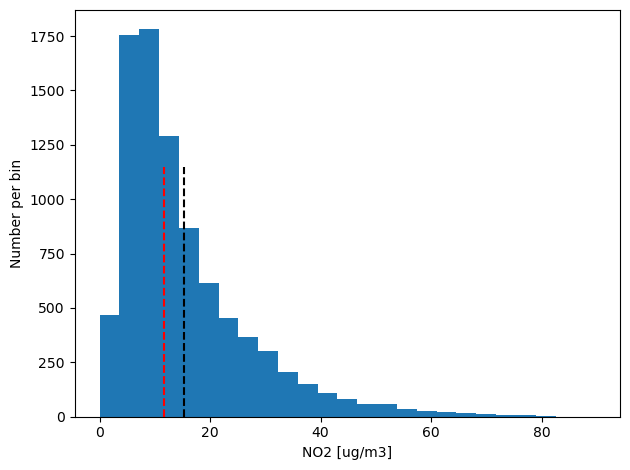

In [42]:
# Import packages needed to plot histogram:
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
# Define plot window:
fig, axs = plt.subplots(1, 1, sharey=True, tight_layout=True)
# Declare number of bins:
n_bins = 25
# Plot the histogram:
axs.hist(KC1_NO2_2024, bins=n_bins)
# Add axes labels:
axs.set_ylabel('Number per bin')
axs.set_xlabel('NO2 [ug/m3]')
# Identify location of mean:
axs.vlines(x=np.nanmean(KC1_NO2_2024), ymin=0, ymax=1150, colors='k', linestyles='--')
# Identify location of median:
axs.vlines(x=np.nanmedian(KC1_NO2_2024), ymin=0, ymax=1150, colors='r', linestyles='--')
